**Imports:**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import kagglehub
from google.colab import files

**Configuration:**

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS = 10

LEARING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

NUM_WORKERS = 2

MODEL_PATH = "/content/oct_c8_resnet18_best.pth"

print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


**Download Dataset:**

In [ ]:
dataset_path = kagglehub.dataset_download(
    "obulisainaren/retinal-oct-c8"
)

print("Dataset Path:")
print(dataset_path)

Using Colab cache for faster access to the 'retinal-oct-c8' dataset.
Dataset Path:
/kaggle/input/retinal-oct-c8


**Find Dataset Directories:**

In [ ]:
def find_directory(root, directory_name):
  for current_root, dirs, files in os.walk(root):
    if directory_name in dirs:
      return os.path.join(current_root, directory_name)
  return None

train_dir = find_directory(dataset_path, "train")
val_dir = find_directory(dataset_path, "val")
test_dir = find_directory(dataset_path, "test")

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: /kaggle/input/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/train
Validation: /kaggle/input/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/val
Test: /kaggle/input/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/test


**Dataset Information:**

In [ ]:
classes = sorted([
    name for name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, name))
])

print("Classes:")

for index, class_name in enumerate(classes):
  print(f"{index}: {class_name}")

print(f"\nNumber Of Classes: {len(classes)}")

Classes:
0: AMD
1: CNV
2: CSR
3: DME
4: DR
5: DRUSEN
6: MH
7: NORMAL

Number Of Classes: 8


**Class Distribution:**

In [ ]:
def count_images(directory):
    counts = {}

    for class_name in classes:
        class_path = os.path.join(directory, class_name)

        counts[class_name] = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

    return counts

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

distribution = pd.DataFrame({
    "Class": classes,
    "Train": [train_counts[c] for c in classes],
    "Validation": [val_counts[c] for c in classes],
    "Test": [test_counts[c] for c in classes]
})

distribution

,Class,Train,Validation,Test
0,AMD,2300,350,350
1,CNV,2300,350,350
2,CSR,2300,350,350
3,DME,2300,350,350
4,DR,2300,350,350
5,DRUSEN,2300,350,350
6,MH,2300,350,350
7,NORMAL,2300,350,350


**Visualize Samples:**

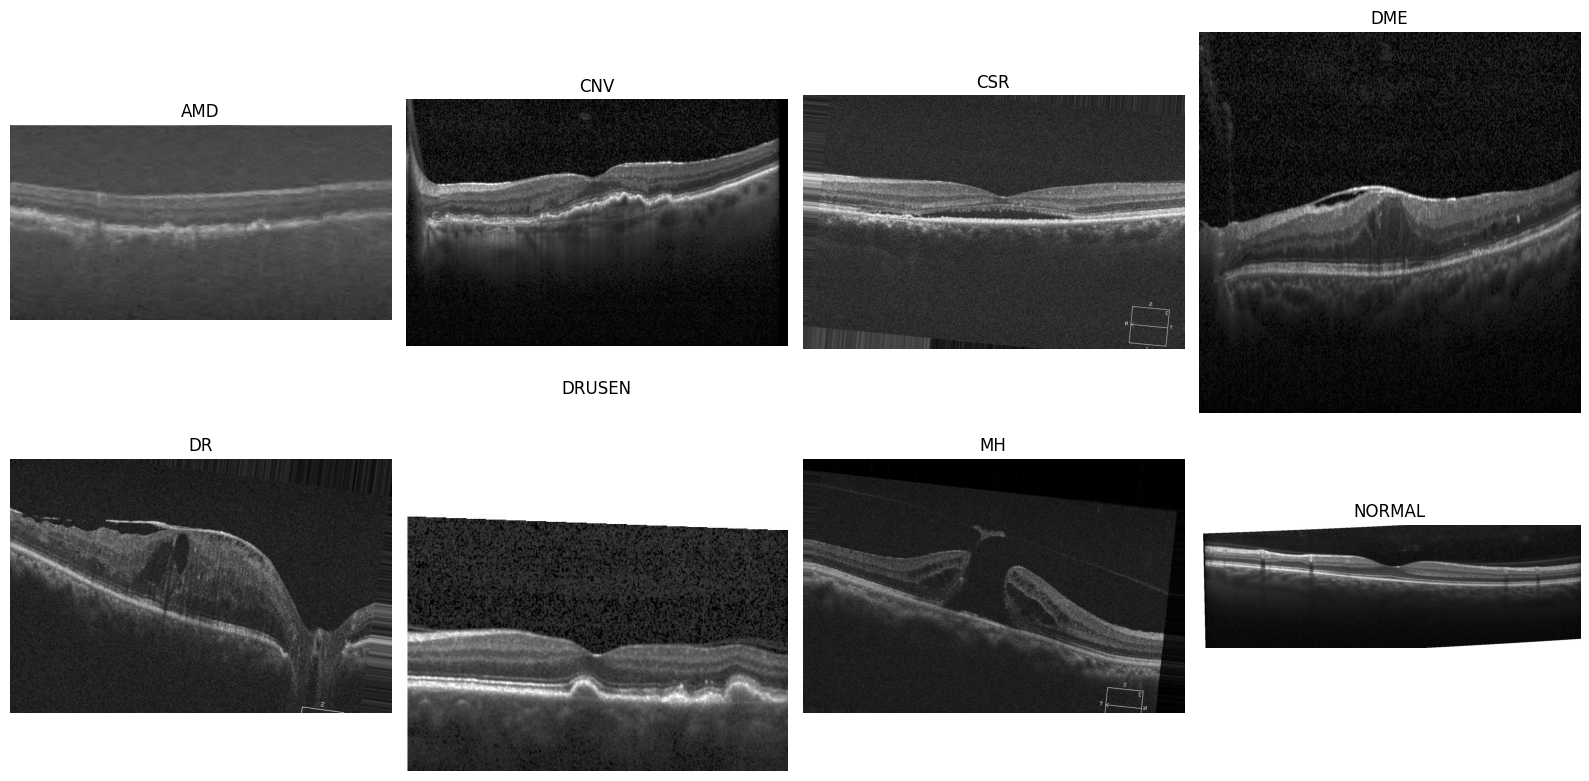

In [ ]:
sample_images = []

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_file = random.choice(image_files)

    sample_images.append(
        (os.path.join(class_path, image_file), class_name)
    )

plt.figure(figsize=(16, 8))

for index, (image_path, class_name) in enumerate(sample_images):
    image = Image.open(image_path)

    plt.subplot(2, 4, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Image Transforms:**

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**Create Datasets:**

In [ ]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=train_transform)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=train_transform)

print(f"Training Images: {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")
print(f"Test Images: {len(test_dataset)}")
print("\nClass Mapping:")
print(train_dataset.class_to_idx)

Training Images: 18400
Validation Images: 2800
Test Images: 2800

Class Mapping:
{'AMD': 0, 'CNV': 1, 'CSR': 2, 'DME': 3, 'DR': 4, 'DRUSEN': 5, 'MH': 6, 'NORMAL': 7}


**Create DataLoaders:**

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Training Batches: {len(train_loader)}")
print(f"Validation Batches: {len(val_loader)}")
print(f"Test Batches: {len(test_loader)}")

Training Batches: 288
Validation Batches: 44
Test Batches: 44


**Load Pretrained ResNet18:**

In [ ]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(classes)
)

model = model.to(DEVICE)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


Linear(in_features=512, out_features=8, bias=True)


**Training Setup:**

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Training Setup Ready")

Training Setup Ready


**Training Loop:**

In [ ]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []
best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_accuracy = correct / total

    scheduler.step(val_accuracy)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )
        best_marker = " ← Best"

    else:
        best_marker = ""

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f} "
        f"LR: {current_lr:.1e}"
        f"{best_marker}"
    )

print("\nTraining Completed.")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")

Epoch [1/10] Train Loss: 0.0473 Train Acc: 0.9838 Val Loss: 0.1265 Val Acc: 0.9643 LR: 1.0e-04 ← Best
Epoch [2/10] Train Loss: 0.0454 Train Acc: 0.9847 Val Loss: 0.1019 Val Acc: 0.9675 LR: 1.0e-04 ← Best
Epoch [3/10] Train Loss: 0.0424 Train Acc: 0.9854 Val Loss: 0.1144 Val Acc: 0.9689 LR: 1.0e-04 ← Best
Epoch [4/10] Train Loss: 0.0359 Train Acc: 0.9874 Val Loss: 0.1018 Val Acc: 0.9711 LR: 1.0e-04 ← Best
Epoch [5/10] Train Loss: 0.0351 Train Acc: 0.9888 Val Loss: 0.1153 Val Acc: 0.9661 LR: 1.0e-04
Epoch [6/10] Train Loss: 0.0320 Train Acc: 0.9888 Val Loss: 0.1281 Val Acc: 0.9646 LR: 1.0e-04
Epoch [7/10] Train Loss: 0.0232 Train Acc: 0.9919 Val Loss: 0.1292 Val Acc: 0.9686 LR: 5.0e-05
Epoch [8/10] Train Loss: 0.0159 Train Acc: 0.9946 Val Loss: 0.1059 Val Acc: 0.9711 LR: 5.0e-05
Epoch [9/10] Train Loss: 0.0132 Train Acc: 0.9954 Val Loss: 0.1149 Val Acc: 0.9657 LR: 5.0e-05
Epoch [10/10] Train Loss: 0.0099 Train Acc: 0.9967 Val Loss: 0.1007 Val Acc: 0.9739 LR: 5.0e-05 ← Best

Training Comp

**Plot Training History:**

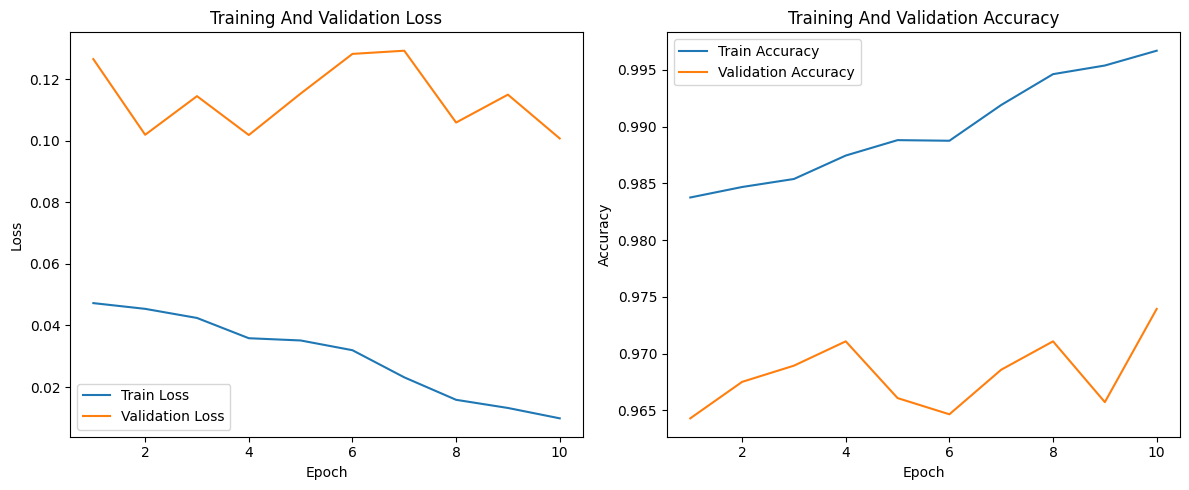

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training And Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training And Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Load Best Model:**

In [ ]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Best Model Loaded.")

Best Model Loaded.


**Test Evaluation:**

In [ ]:
all_predictions = []
all_labels = []

test_correct = 0
test_total = 0

model.eval()

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    outputs = model(images)
    predictions = outputs.argmax(dim=1)
    test_correct += (predictions == labels).sum().item()
    test_total += labels.size(0)
    all_predictions.extend(predictions.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.9779
Test Accuracy: 97.79%


**Classification Report:**

In [ ]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

         AMD     1.0000    1.0000    1.0000       350
         CNV     0.9463    0.9571    0.9517       350
         CSR     1.0000    1.0000    1.0000       350
         DME     0.9735    0.9457    0.9594       350
          DR     1.0000    1.0000    1.0000       350
      DRUSEN     0.9563    0.9371    0.9466       350
          MH     1.0000    1.0000    1.0000       350
      NORMAL     0.9477    0.9829    0.9649       350

    accuracy                         0.9779      2800
   macro avg     0.9780    0.9779    0.9778      2800
weighted avg     0.9780    0.9779    0.9778      2800



**Confusion Matrix:**

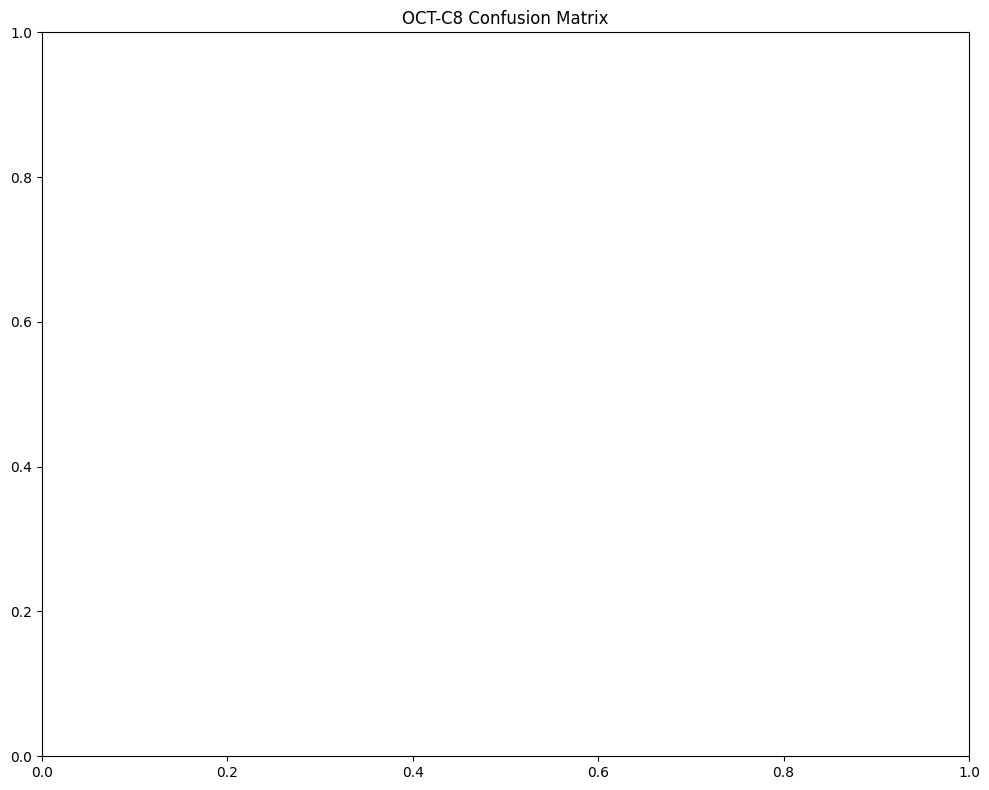

In [ ]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=45
)

plt.title("OCT-C8 Confusion Matrix")
plt.tight_layout()
plt.show()

**Visualize Predictions:**

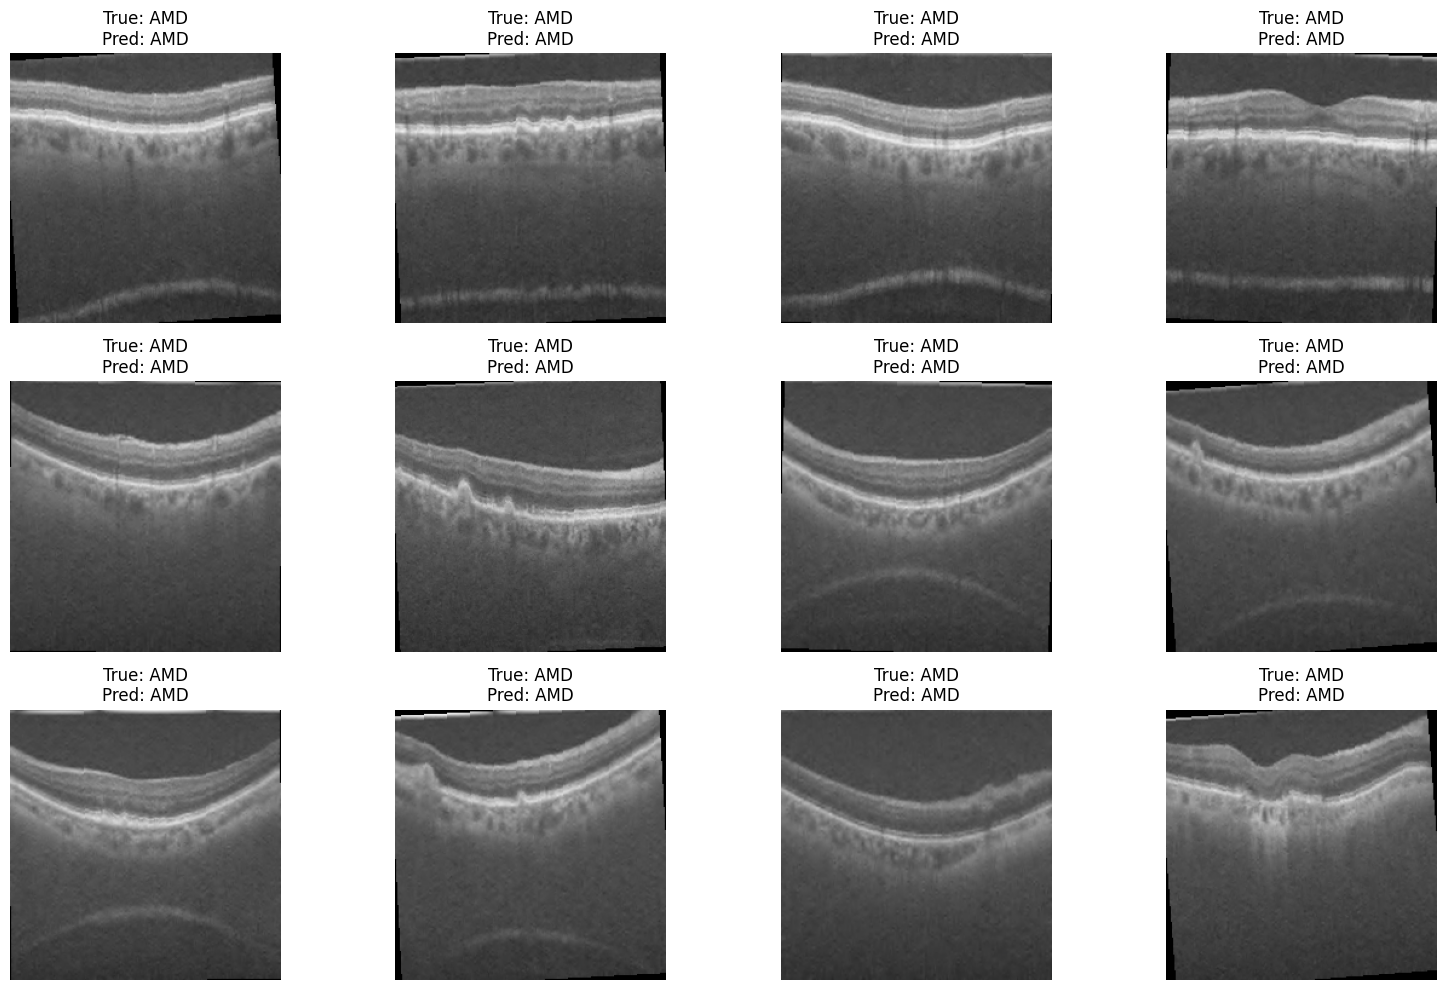

In [ ]:
model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(DEVICE)

with torch.no_grad():
  outputs = model(images_device)
  predictions = outputs.argmax(dim=1)

images = images.cpu()
labels = labels.cpu()
predictions = predictions.cpu()

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

images = images * std + mean
images = torch.clamp(images, 0, 1)

plt.figure(figsize=(16, 10))

for index in range(min(12, len(images))):
    plt.subplot(3, 4, index + 1)
    image = images[index].permute(1, 2, 0)

    plt.imshow(image)

    true_label = classes[labels[index]]
    predicted_label = classes[predictions[index]]

    title = (
        f"True: {true_label}\n"
        f"Pred: {predicted_label}"
    )

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Save Model:**

In [ ]:
final_model_path = "/content/savalanai_oct_c8_resnet18_best.pth"

torch.save(
    model.state_dict(),
    final_model_path
)

print("Model Saved:")
print(final_model_path)

Model Saved:
/content/savalanai_oct_c8_resnet18_best.pth


**Download Best Model:**

In [ ]:
files.download(final_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Single Image Prediction:**

In [ ]:
def predict_image(image_path, model, transform, classes, device):
  image = Image.open(image_path).convert("RGB")
  image_tensor = transform(image)
  image_tensor = image_tensor.unsqueeze(0)
  image_tensor = image_tensor.to(device)

  model.eval()

  with torch.no_grad():
    outputs = model(image_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    predicted_index = probabilities.argmax(dim=1).item()
    confidence = probabilities[0][predicted_index].item()

  predicted_class = classes[predicted_index]

  plt.figure(figsize=(6, 6))
  plt.imshow(image)
  plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%")
  plt.axis("off")
  plt.show()

  return predicted_class, confidence

**Test Single Image:**

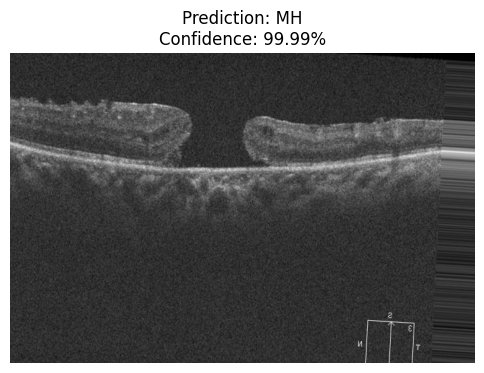

Image: /kaggle/input/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/test/MH/mh_test_1123.jpg
Predicted Class: MH
Confidence: 99.99%
Actual Class: MH


In [ ]:
test_class = random.choice(classes)

test_class_path = os.path.join(test_dir, test_class)

test_image_file = random.choice([
    file for file in os.listdir(test_class_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

test_image_path = os.path.join(test_class_path, test_image_file)

predicted_class, confidence = predict_image(test_image_path, model, eval_transform, classes, DEVICE)

print(f"Image: {test_image_path}")
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence * 100:.2f}%")
print(f"Actual Class: {test_class}")